# Cybersecurity Intrusion

Cybersecurity systems often need to identify suspicious network sessions so potential attacks can be identified and investigated. Our goal is to build a machine learning model that predicts whether a network session is **Normal** or an **Attack** using network behavior, login activity, browser information, encryption type, IP reputation, and other features from our [dataset](https://www.kaggle.com/datasets/dnkumars/cybersecurity-intrusion-detection-dataset).

This is important because missing an attack can be costly. A model that identifies suspicious sessions could help security teams prioritize which sessions need closer review. However, false alarms also matter because too many unnecessary alerts can mislead security teams. Therefore, this project evaluates performance using not only accuracy, but also precision, recall, F1, F2, ROC AUC, and average precision, with extra focus on recall and F2-score because catching attacks is especially important.

Target Feature: '**attack_detected**'
- 0 --> Normal
- 1 --> Attack

## Feature Descriptions

| Feature | Type | Description |
|---|---|---|
| `session_id` | Identifier | Unique ID for each session record |
| `network_packet_size` | Numeric | Size of the network packet associated with the session |
| `protocol_type` | Categorical | Network protocol used by the session: **TCP**, **UDP**, or **ICMP** |
| `login_attempts` | Numeric | Number of login attempts for the session |
| `session_duration` | Numeric | Duration of the session |
| `encryption_used` | Categorical | Encryption method used: **AES**, **DES**, or **None** |
| `ip_reputation_score` | Numeric | Score representing how trustworthy or suspicious the IP address appears on a 0-1 scale, with **1** being suspicious |
| `failed_logins` | Numeric | Number of failed login attempts for the session |
| `browser_type` | Categorical | Browser associated with the session: **Chrome**, **Firefox**, **Edge**, **Safari**, and **Unknown**. |
| `unusual_time_access` | Binary | Indicates whether access occurred at an unusual time |
| `attack_detected` | Target | Indicates whether the session was labeled as an attack. `0 = Normal`, `1 = Attack` |

### Import libraries and Load data

In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns
from pathlib import Path
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
                             accuracy_score, average_precision_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay,
                             f1_score, fbeta_score, make_scorer,
                             precision_score, recall_score,
                             PrecisionRecallDisplay, roc_auc_score,
                             )
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import qrcode

#sns theme setup
sns.set_theme(style="ticks", context="talk")

# Consts
RANDOM_STATE = 29
TARGET_COLUMN = "attack_detected"

# Load data
data_path = Path("..")/"data"/"cybersecurity_intrusion_data.csv"
raw_intrusion_df = pd.read_csv(data_path, keep_default_na=False) # Dataset has none as an actual field value, so keep it

## 1. Check and Clean the Data

First we check that the data is loaded as expected looking at the head, tail, and shape of the data (rows & cols)

In [2]:
raw_intrusion_df

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0
...,...,...,...,...,...,...,...,...,...,...,...
9532,SID_09533,194,ICMP,3,226.049889,AES,0.517737,3,Chrome,0,1
9533,SID_09534,380,TCP,3,182.848475,None,0.408485,0,Chrome,0,0
9534,SID_09535,664,TCP,5,35.170248,AES,0.359200,1,Firefox,0,0
9535,SID_09536,406,TCP,4,86.664703,AES,0.537417,1,Chrome,1,0


* The data appears to be loaded correctly as the columns title and data appear to line up as expected.
  
<br>
Next We'll look at column details and check for any missing or duplicate data

In [3]:
raw_intrusion_df.info()
print()

display(pd.DataFrame([
    {
        "rows": len(raw_intrusion_df),
        "columns": raw_intrusion_df.shape[1],
        "missing_values": int(raw_intrusion_df.isna().sum().sum()), # Need both sum() to work
        "duplicate_rows": int(raw_intrusion_df.duplicated().sum()),
    }
]).round(3))

<class 'pandas.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   str    
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   str    
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      9537 non-null   str    
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   str    
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), str(4)
memory usage: 819.7 KB



,rows,columns,missing_values,duplicate_rows
0,9537,11,0,0


The raw dataset has 11 columns with no missing values or duplicate rows that appear in the dataset, so the only direct cleaning step in the final notebook is dropping **session_id** since that is a unique identifier and holds no predictive merit for the model to train with.

In [4]:
raw_intrusion_df = raw_intrusion_df.drop(columns=["session_id"], errors="ignore")

raw_intrusion_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   network_packet_size  9537 non-null   int64  
 1   protocol_type        9537 non-null   str    
 2   login_attempts       9537 non-null   int64  
 3   session_duration     9537 non-null   float64
 4   encryption_used      9537 non-null   str    
 5   ip_reputation_score  9537 non-null   float64
 6   failed_logins        9537 non-null   int64  
 7   browser_type         9537 non-null   str    
 8   unusual_time_access  9537 non-null   int64  
 9   attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), str(3)
memory usage: 745.2 KB


<br>
We'll look at statistical data about the numeric features

In [5]:
raw_intrusion_df.describe().T

,count,mean,std,min,25%,50%,75%,max
network_packet_size,9537.0,500.430639,198.379364,64.000000,365.000000,499.000000,635.000000,1285.000000
login_attempts,9537.0,4.032086,1.963012,1.000000,3.000000,4.000000,5.000000,13.000000
session_duration,9537.0,792.745312,786.560144,0.500000,231.953006,556.277457,1105.380602,7190.392213
ip_reputation_score,9537.0,0.331338,0.177175,0.002497,0.191946,0.314778,0.453388,0.924299
failed_logins,9537.0,1.517773,1.033988,0.000000,1.000000,1.000000,2.000000,5.000000
unusual_time_access,9537.0,0.149942,0.357034,0.000000,0.000000,0.000000,0.000000,1.000000
attack_detected,9537.0,0.447101,0.497220,0.000000,0.000000,0.000000,1.000000,1.000000


**Some Observations**:
- An interesting observation is the max **login_attempts** appear to be 13 and max **failed_logins** appear to be 5
- There appears to be a lot of deviation with **network_packet_size** and **session_duration**
- **ip_reputation_score** is scaled from 0 to 1, where higher values indicate more suspicious IP behavior
- **attack_detected** and **unusual time access** are binary values in the dataset
<br>

## 2. EDA Visuals

We'll explore the data to understand our data. Our first look will be at our label **attack_detected** to see how much of our data consists of normal/attack


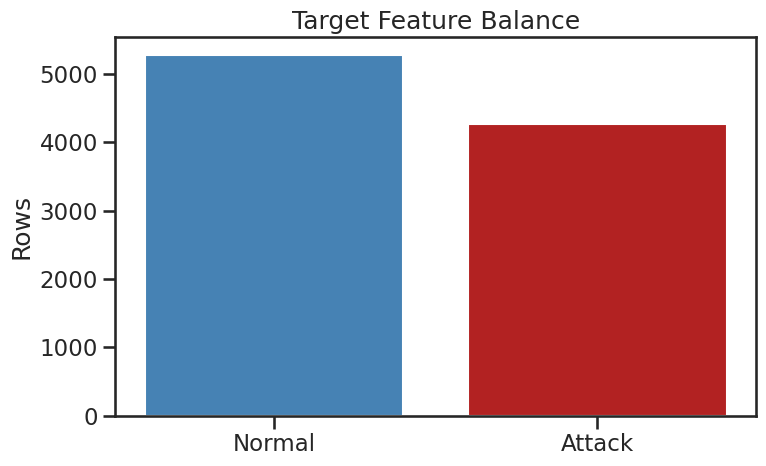

,normal count,attack count,attack proportion
0,5273,4264,44.71%


In [6]:
# Set up EDA df for visuals
label_map = {0: "Normal", 1: "Attack"}
eda_plot_df = raw_intrusion_df.copy()
eda_plot_df["attack_label"] = eda_plot_df[TARGET_COLUMN].map(label_map)
palette = {"Normal": "steelblue", "Attack": "firebrick",}

# Create count plot visual
class_counts = eda_plot_df["attack_label"].value_counts().reindex(["Normal", "Attack"])
plt.figure(figsize=(8, 5))
plt.bar(class_counts.index, class_counts.values, color=["steelblue", "firebrick"])
plt.title("Target Feature Balance")
plt.ylabel("Rows")
plt.xlabel("")
plt.tight_layout()
plt.show()

# Create summary for numbers
target_counts = pd.DataFrame([
    {
        "normal count": int((raw_intrusion_df[TARGET_COLUMN] == 0).sum()),
        "attack count": int((raw_intrusion_df[TARGET_COLUMN] == 1).sum()),
        "attack proportion": raw_intrusion_df[TARGET_COLUMN].mean(),
    }
])
display(target_counts.style.format({
        "attack proportion": "{:.2%}",
    }))

- Higher normal counts, but reasonably balanced

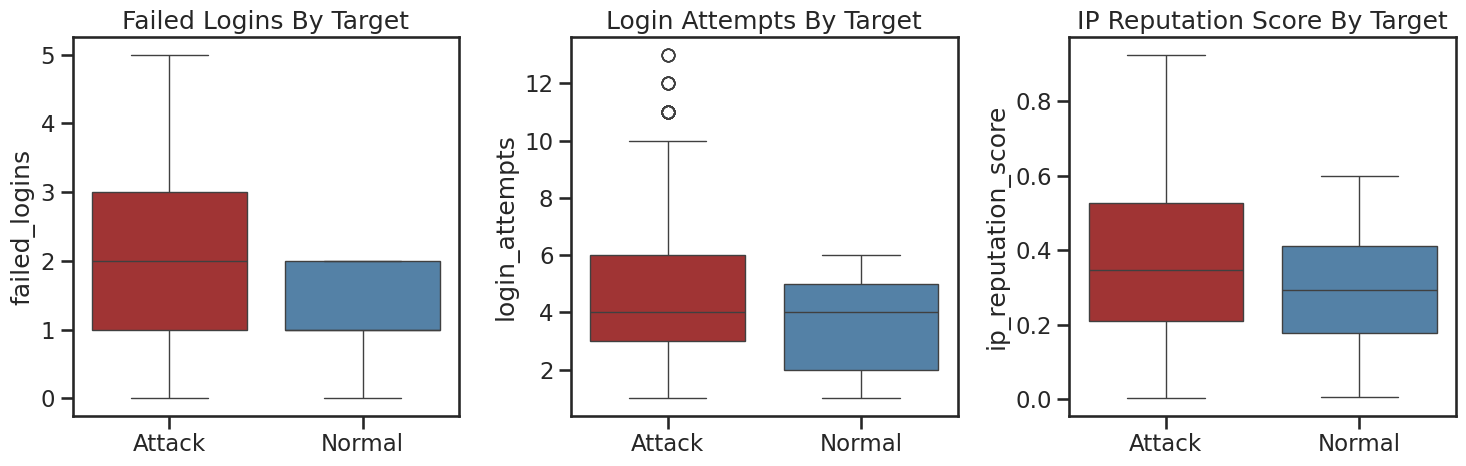

In [7]:
# Create box plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=eda_plot_df, x="attack_label", y="failed_logins", ax=axes[0], hue="attack_label", hue_order=["Normal", "Attack"], palette=palette)
axes[0].set_title("Failed Logins By Target")
axes[0].set_xlabel("")
axes[0].set_ylabel("failed_logins")

sns.boxplot(data=eda_plot_df, x="attack_label", y="login_attempts", ax=axes[1], hue="attack_label", hue_order=["Normal", "Attack"], palette=palette)
axes[1].set_title("Login Attempts By Target")
axes[1].set_xlabel("")
axes[1].set_ylabel("login_attempts")

sns.boxplot(data=eda_plot_df, x="attack_label", y="ip_reputation_score", ax=axes[2], hue="attack_label", hue_order=["Normal", "Attack"], palette=palette)
axes[2].set_title("IP Reputation Score By Target")
axes[2].set_xlabel("")
axes[2].set_ylabel("ip_reputation_score")

plt.tight_layout()
plt.show()

- The boxplots suggest that Login behavior and IP reputation provides a distinguishing signal between normal and attack. 

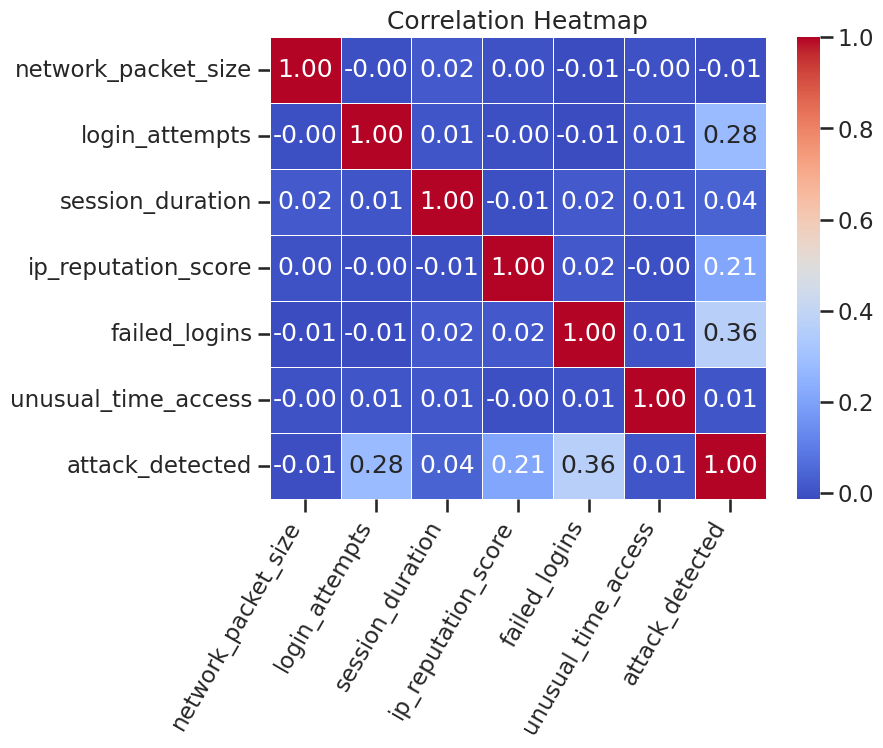

In [8]:
# Create heatmap
eda_heatmap_columns = [col for col in eda_plot_df.select_dtypes(include=["number"]).columns.tolist() if col != TARGET_COLUMN] + [TARGET_COLUMN]
plt.figure(figsize=(8,6))
sns.heatmap(eda_plot_df[eda_heatmap_columns].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.xticks(rotation=60, ha="right")
plt.show()

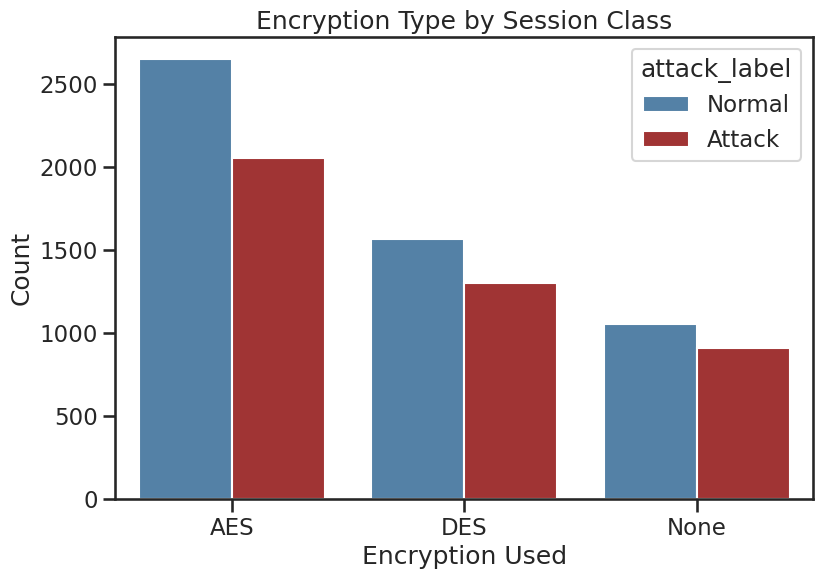

In [9]:
# Create histogram
plt.figure(figsize=(9, 6))
sns.countplot(data=eda_plot_df, x="encryption_used", order=["AES", "DES", "None"], hue="attack_label", hue_order=["Normal", "Attack"], palette=palette)
plt.title("Encryption Type by Session Class")
plt.xlabel("Encryption Used")
plt.ylabel("Count")
plt.show()

## 3. Failed Logins > Login Attempts Issue

During EDA, we found rows where `failed_logins` exceeded `login_attempts`. This logically doesn't make sense as you cannot fail more than you attempt.

In [10]:
invalid_rows = eda_plot_df.loc[raw_intrusion_df["failed_logins"] > raw_intrusion_df["login_attempts"]].copy()
eda_plot_df["failed_login_validity"] = np.where(eda_plot_df["failed_logins"] > eda_plot_df["login_attempts"], "Invalid", "Valid")

# Display sample of invalid failed login rows
print("Sample of invalid rows:")
display(
    invalid_rows[
        [
            "login_attempts",
            "failed_logins",
            "ip_reputation_score",
            "session_duration",
            "browser_type",
            "unusual_time_access",
            TARGET_COLUMN,
        ]
    ].head(5)
)

Sample of invalid rows:


,login_attempts,failed_logins,ip_reputation_score,session_duration,browser_type,unusual_time_access,attack_detected
17,1,2,0.136729,87.641002,Firefox,0,0
33,2,3,0.110269,1039.101186,Chrome,0,1
59,1,2,0.259419,989.889796,Edge,0,1
69,1,2,0.408654,1105.380602,Chrome,0,1
101,2,3,0.204681,294.584967,Chrome,0,1


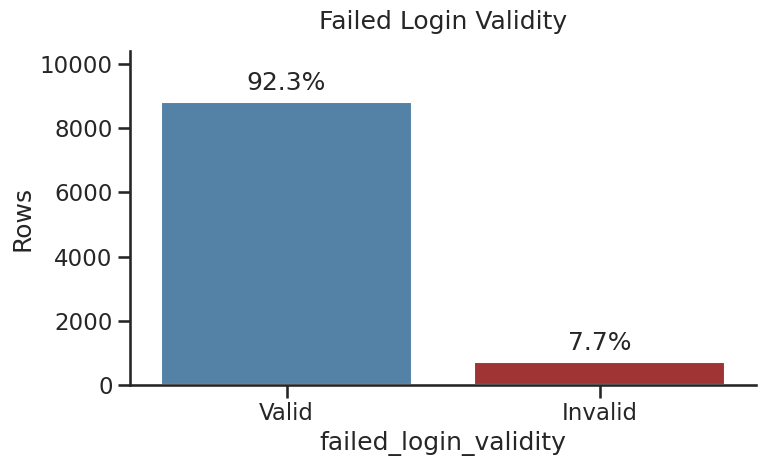

,valid rows,invalid rows,percent invalid,invalid attack proportion,valid attack proportion
0,8807,730,7.65%,70.68%,42.56%


In [11]:
# Display valid / invalid visual
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=eda_plot_df, x="failed_login_validity", hue="failed_login_validity", hue_order=["Valid", "Invalid"], palette={"Valid": "steelblue", "Invalid": "firebrick"})
max_count = eda_plot_df["failed_login_validity"].value_counts().max()
ax.set_ylim(0, max_count * 1.18)
plt.title("Failed Login Validity", pad=16)
plt.ylabel("Rows")
total_rows = len(eda_plot_df)
for p in ax.patches:
    height = p.get_height()
    pct = height / total_rows * 100
    ax.annotate(f"{pct:.1f}%", (p.get_x() + p.get_width() / 2, height), ha="center", va="bottom", xytext=(0, 5), textcoords="offset points")
sns.despine()
plt.tight_layout()
plt.show()

# Display summary of valid / invalid failed logins 
invalid_summary = pd.DataFrame([
    {
        "valid rows": len(eda_plot_df.loc[eda_plot_df["failed_logins"] <= eda_plot_df["login_attempts"]].copy()),
        "invalid rows": len(invalid_rows),
        "percent invalid": len(invalid_rows) / len(eda_plot_df),
        "invalid attack proportion": invalid_rows[TARGET_COLUMN].mean(),
        "valid attack proportion": eda_plot_df.loc[eda_plot_df["failed_logins"] <= eda_plot_df["login_attempts"], TARGET_COLUMN].mean(),
    }
])
display(
    invalid_summary.style.format({
        "percent invalid": "{:.2%}",
        "invalid attack proportion": "{:.2%}",
        "valid attack proportion": "{:.2%}",
    })
)

* Several strategies were tested such as: removing invalid rows, adjusting failed login counts, creating ratio-based features, a few others. However, these approaches only reduced model performance. Thus, the raw dataset was kept so the analysis remained faithful to the source data. However, this issue is still important because it limits how confidently the model could be used in a real-world setting.

## 4. Feature Engineering

The raw dataset is kept as provided with a two engineered features that had the most impact. However, it's a slight improvement.  

Engineered features:

- failed_login_reputation_score = ip_reputation_score × (failed_logins + 1)
- login_attempt_reputation_score = login_attempts × ip_reputation_score

Added engineered features: ['failed_login_reputation_score', 'login_attempt_reputation_score']


,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected,failed_login_reputation_score,login_attempt_reputation_score
0,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1,1.213636,2.427272
1,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0,0.301569,0.904707
2,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1,2.217493,2.217493
3,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1,0.123267,0.493069
4,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0,0.109748,0.274369


Model df shape: (9537, 12)



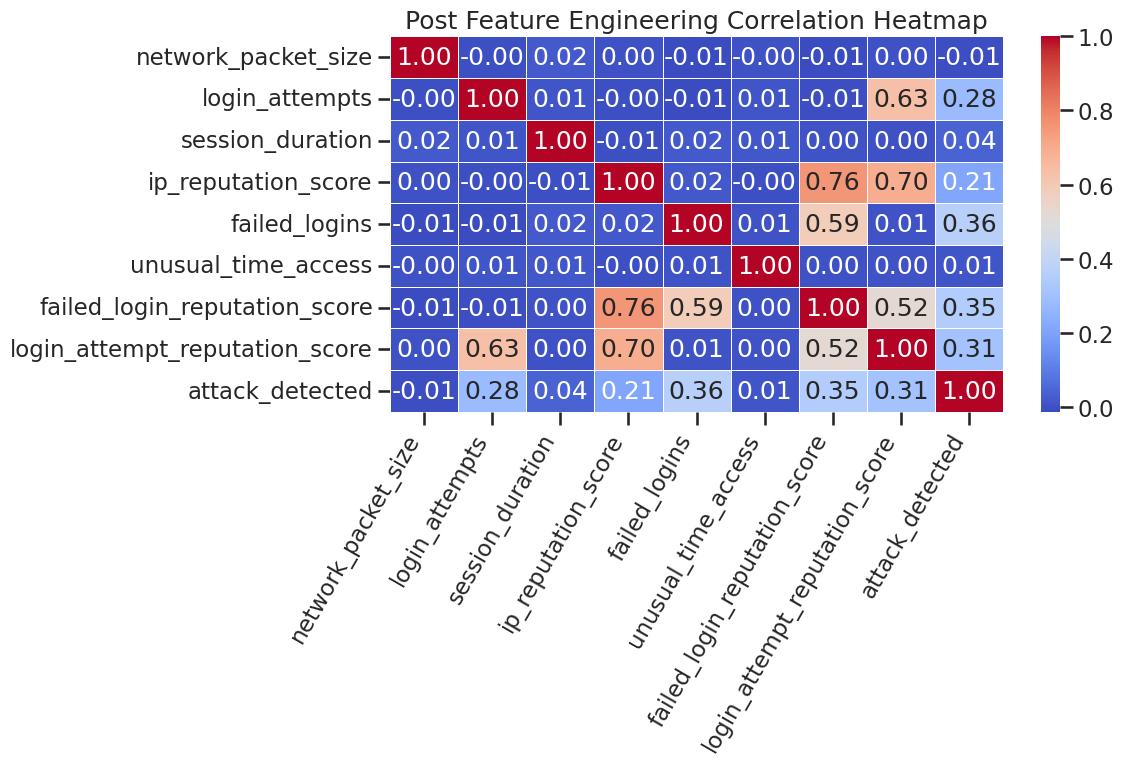

In [12]:
# Function that will add/remove features to create df for model
def feature_engineering(df):
    new_df = df.copy()

    new_df["failed_login_reputation_score"] = new_df["ip_reputation_score"] * (new_df["failed_logins"] + 1)
    new_df["login_attempt_reputation_score"] = new_df["login_attempts"] * new_df["ip_reputation_score"]

    return new_df


# Create df for model to use
model_df = feature_engineering(raw_intrusion_df)
new_feature_columns = [col for col in model_df.select_dtypes(include=["number"]).columns if col not in raw_intrusion_df.columns]

# Display model df with engineered features
print("Added engineered features:", new_feature_columns)
display(model_df.head())
print("Model df shape:", model_df.shape)
print()

# Display heatmap correlation visual
engineer_heatmap_columns = [col for col in model_df.columns.tolist() if col != TARGET_COLUMN] + [TARGET_COLUMN] # Ensure Target col is last
numeric_corr_cols = model_df[engineer_heatmap_columns].corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_corr_cols, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Post Feature Engineering Correlation Heatmap")
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=60, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Modeling Setup

All models used the same preprocessing pipeline:

- Numeric features are standardized with `StandardScaler`
- Categorical features are encoded with `OneHotEncoder`

These preprocessing steps are placed inside a scikit-learn pipeline so the same transformations are applied consistently during cross-validation, final fitting, and prediction.

### Modeling Helper Functions

These helper functions keep the modeling workflow compact as they handle preprocessing via standard scaling & one hot encoding, model creation, evaluation, and creating visuals

In [13]:
# Build preprocessing pipline that automatically scales and onehot encode data for models
def build_preprocessor(X_train):
    # Separate numerical and categorical features
    numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
    categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([("scaler", StandardScaler())]), numeric_features),
            ("cat", Pipeline([("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), categorical_features),
        ]
    )

# Build Models 
def build_models():
    return {
        "BaselineLogisticRegression": LogisticRegression(
            random_state=RANDOM_STATE,
            max_iter=1000
        ),
        "ExtraTrees": ExtraTreesClassifier(
            random_state=RANDOM_STATE,
            n_estimators=500,
            min_samples_leaf=2,
            n_jobs=1,
        ),
        "RandomForest": RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_estimators=500,
            min_samples_leaf=2,
        ),
        "GradientBoosting": GradientBoostingClassifier(
            random_state=RANDOM_STATE,
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            min_samples_split=20,
            min_samples_leaf=10,
            subsample=0.8
        ),
        "HistGradientBoosting": HistGradientBoostingClassifier(
            random_state=RANDOM_STATE,
            learning_rate=0.06,
            max_depth=5,
            max_leaf_nodes=31,
            min_samples_leaf=40,
            l2_regularization=1.0
        ),
        "XGBoost": XGBClassifier(
            random_state=RANDOM_STATE,
            tree_method="hist",
            n_estimators=200,
            learning_rate=0.03,
            max_depth=5,
            min_child_weight=3,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=2.0,
        )
    }

# Get models performance from a threshold to evaluate
def evaluate_probabilities(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "avg_precision": average_precision_score(y_true, y_prob),
    }

# Get model performance to evaluate
def evaluate_model(model, X, y):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    return {
        "accuracy": accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall": recall_score(y, y_pred, zero_division=0),
        "f1": f1_score(y, y_pred, zero_division=0),
        "f2": fbeta_score(y, y_pred, beta=2, zero_division=0),
        "roc_auc": roc_auc_score(y, y_prob),
        "avg_precision": average_precision_score(y, y_prob),
    }


# Create Confusion Matrix, Precision Recall Curve and ROC Curve with trained Model
def plot_model_charts(model, X, y, title_prefix="Model"):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    _, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    ConfusionMatrixDisplay.from_predictions(y, y_pred, display_labels=["Normal", "Attack"], ax=axes[0], cmap="Greens", colorbar=False)
    axes[0].set_title(f"{title_prefix} Confusion Matrix")

    PrecisionRecallDisplay.from_predictions(y, y_prob, ax=axes[1])
    axes[1].set_title(f"{title_prefix} Precision-Recall Curve")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1.02)
    axes[1].set_xticks(np.arange(0, 1.01, 0.2))
    axes[1].set_yticks(np.arange(0, 1.01, 0.2))
    axes[1].set_xticks(np.arange(0, 1.01, 0.1), minor=True)
    axes[1].set_yticks(np.arange(0, 1.01, 0.1), minor=True)
    axes[1].xaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    axes[1].yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    axes[1].tick_params(axis="x", labelrotation=0)
    plt.setp(axes[1].get_xticklabels(), ha="center")
    axes[1].grid(True, which="major", alpha=0.25)
    axes[1].grid(True, which="minor", alpha=0.15)
    pr_legend = axes[1].legend(loc="lower center", bbox_to_anchor=(0.5, 0.03), fontsize=16, handlelength=1.8, handletextpad=0.4, borderpad=0.4)
    for line in pr_legend.get_lines():
        line.set_linewidth(1.25)

    RocCurveDisplay.from_predictions(y, y_prob, ax=axes[2])
    axes[2].set_title(f"{title_prefix} ROC Curve")
    axes[2].set_xlabel("False Positive Rate")
    axes[2].set_ylabel("True Positive Rate")
    axes[2].set_xlim(0, 1)
    axes[2].set_ylim(0, 1.02)
    axes[2].set_xticks(np.arange(0, 1.01, 0.2))
    axes[2].set_yticks(np.arange(0, 1.01, 0.2))
    axes[2].set_xticks(np.arange(0, 1.01, 0.1), minor=True)
    axes[2].set_yticks(np.arange(0, 1.01, 0.1), minor=True)
    axes[2].xaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    axes[2].yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    axes[2].tick_params(axis="x", labelrotation=0)
    plt.setp(axes[2].get_xticklabels(), ha="center")
    axes[2].grid(True, which="major", alpha=0.25)
    axes[2].grid(True, which="minor", alpha=0.15)
    roc_legend = axes[2].legend(loc="lower center", bbox_to_anchor=(0.5, 0.03), fontsize=15, handlelength=1.8, handletextpad=0.4, borderpad=0.4)
    for line in roc_legend.get_lines():
        line.set_linewidth(1.25)

    plt.tight_layout()
    plt.show()


## 6. Train/Test Split
A stratified 80/20 split is used so the train and test sets preserve the same attack/normal ratio

In [14]:
# Seperate target feature
X = model_df.drop(columns=[TARGET_COLUMN]).copy()
y = model_df[TARGET_COLUMN].astype(int).copy()

# Create 80/20 train and test splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

# Display summary of train/test split
split_summary = pd.DataFrame([
    {
        "split": "train",
        "X shape": X_train.shape,
        "y shape": str(y_train.shape[0]),
        "attack proportion": y_train.mean(),
        "% of data": f"{len(X_train) / len(model_df):.0%}"
    },
    {
        "split": "test",
        "X shape": X_test.shape,
        "y shape": str(y_test.shape[0]),
        "attack proportion": y_test.mean(),
        "% of data": f"{len(X_test) / len(model_df):.0%}"

    },
])
display(split_summary.round(3))

,split,X shape,y shape,attack proportion,% of data
0,train,"(7629, 11)",7629,0.447,80%
1,test,"(1908, 11)",1908,0.447,20%


## 7. Model Comparison With Cross-Validation

`BaselineLogisticRegression` is included as a simple baseline model so that the candidate models can be compared against a straightforward linear approach.

Using the preprocessing pipeline described earlier, each candidate model is evaluated with cross-validation on the training data only.

Results are sorted by `f2_mean` because F2 gives more weight to recall while still considering precision, aiming to find the model that catches the most attacks.

In [15]:
# Build the models and preprocesser
models = build_models()
preprocessor = build_preprocessor(X_train)

# Set up stratified cross-validation folds and the scoring metrics.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "f2": make_scorer(fbeta_score, beta=2),
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
}

model_pipelines = {}
model_results = []

# Evaluate each model using the same preprocesser and same cross-validation splits
for name, model in models.items():
    # Build and save the full pipeline for model
    pipeline = Pipeline([("preprocessor", preprocessor), ("model", model)])
    model_pipelines[name] = pipeline

    # Collect scores across the five folds.
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)

    # Store the mean and standard deviation for each metric
    row = {"model": name}
    for metric in scoring:
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()
    model_results.append(row)

# Rank the models by recall-weighted performance and display the comparison table
cv_results = (pd.DataFrame(model_results).sort_values(by=["f2_mean", "recall_mean", "average_precision_mean"], ascending=False).reset_index(drop=True))
display(cv_results[[
    "model",
    "accuracy_mean",
    "recall_mean",
    "precision_mean",
    "f2_mean",
    "f1_mean",
    "roc_auc_mean",
    "average_precision_mean",
]].round(3))

,model,accuracy_mean,recall_mean,precision_mean,f2_mean,f1_mean,roc_auc_mean,average_precision_mean
0,GradientBoosting,0.892,0.761,0.996,0.799,0.863,0.884,0.913
1,RandomForest,0.890,0.758,0.996,0.796,0.861,0.887,0.915
2,XGBoost,0.890,0.755,0.998,0.794,0.860,0.885,0.913
3,ExtraTrees,0.882,0.759,0.972,0.794,0.852,0.883,0.912
4,HistGradientBoosting,0.890,0.754,0.998,0.793,0.859,0.883,0.912
5,BaselineLogisticRegression,0.753,0.704,0.733,0.710,0.718,0.817,0.822


## 8. Final Model Choice

The final model is `GradientBoosting` as it has the highest `f2_mean`, `recall_mean`, `f1_mean`, and `accuracy_mean`. We will now fit with the full training set

In [16]:
# Get the selected final model and fit it on the full training split
final_model_name = cv_results.iloc[0]["model"]
final_model_pipeline = model_pipelines[final_model_name]
final_model_pipeline.fit(X_train, y_train)
train_metrics = evaluate_model(final_model_pipeline, X_train, y_train)

# Display the chosen model and its training metrics
display(pd.DataFrame([{
    "final_model": final_model_name,
    "train_accuracy": train_metrics["accuracy"],
    "train_precision": train_metrics["precision"],
    "train_recall": train_metrics["recall"],
    "train_f1": train_metrics["f1"],
    "train_f2": train_metrics["f2"],
    "train_roc_auc": train_metrics["roc_auc"],
    "train_avg_precision": train_metrics["avg_precision"],
}]).round(3))

,final_model,train_accuracy,train_precision,train_recall,train_f1,train_f2,train_roc_auc,train_avg_precision
0,GradientBoosting,0.894,1.0,0.764,0.866,0.802,0.953,0.959


## 9. Final Test Performance

Now we will test the final model with the test set

Classification Report:
              precision    recall  f1-score   support

      Normal       0.85      1.00      0.92      1055
      Attack       1.00      0.78      0.88       853

    accuracy                           0.90      1908
   macro avg       0.93      0.89      0.90      1908
weighted avg       0.92      0.90      0.90      1908



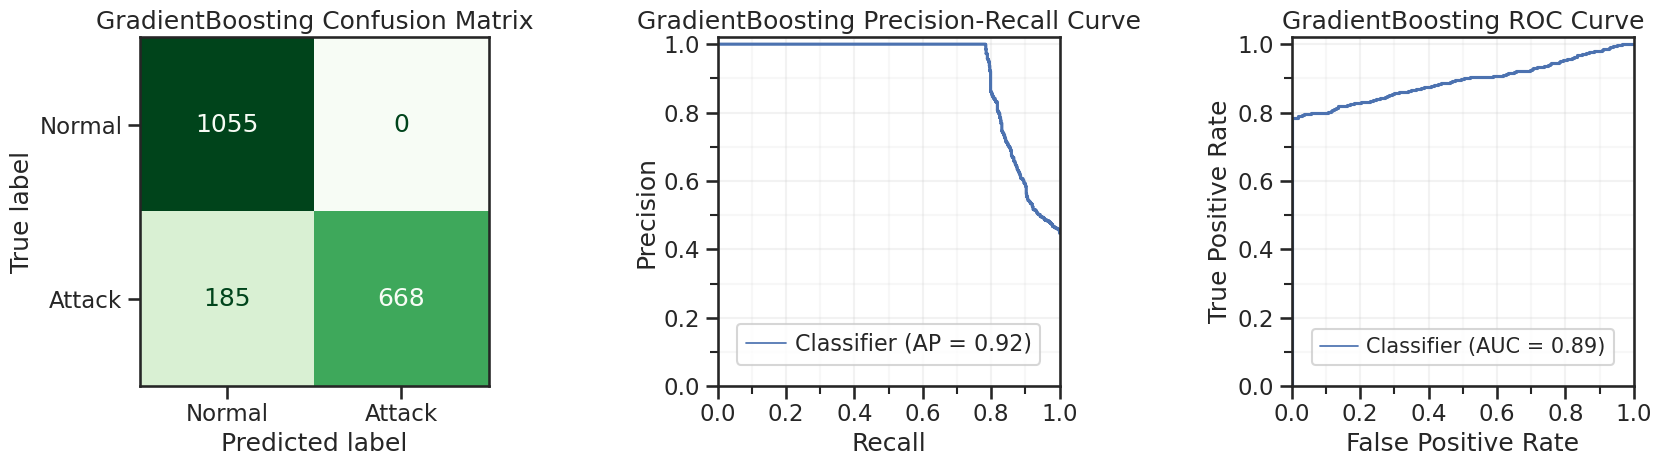

,final_model,test_accuracy,test_precision,test_recall,test_f1,test_f2,test_roc_auc,test_avg_precision
0,GradientBoosting,0.903,1.0,0.783,0.878,0.819,0.892,0.921


In [17]:
y_test_pred = final_model_pipeline.predict(X_test)
test_metrics = evaluate_model(final_model_pipeline, X_test, y_test)

# Display final test metrics
print("Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=["Normal", "Attack"]))
plot_model_charts(final_model_pipeline, X_test, y_test, title_prefix=f"{final_model_name}")
#display(pd.DataFrame([test_metrics]).round(3))
display(pd.DataFrame([{
    "final_model": final_model_name,
    "test_accuracy": test_metrics["accuracy"],
    "test_precision": test_metrics["precision"],
    "test_recall": test_metrics["recall"],
    "test_f1": test_metrics["f1"],
    "test_f2": test_metrics["f2"],
    "test_roc_auc": test_metrics["roc_auc"],
    "test_avg_precision": test_metrics["avg_precision"],
}]).round(3))

- When the model predicts Attack, it is extremely precise, but it misses a decent chunk of attacks.

## 10. Threshold Sensitivity For GradientBoosting

This section compares the default `0.50` threshold to a lower `0.30` threshold for the final `GradientBoosting` model using cross-validated predicted probabilities on the training split. We check if lowering the threshold will help boost recall at the expense of lower precision.

In [18]:
# Thresholds to compare
thresholds = [0.50, 0.30]

# Get cross-validated attack probabilities from the final model
cross_validated_probabilities = cross_val_predict(final_model_pipeline, X_train, y_train, cv=cv, method="predict_proba")[:, 1]

threshold_rows = []
# Compare model performance at each threshold
for threshold in thresholds:
    y_threshold_pred = (cross_validated_probabilities >= threshold).astype(int)
    _, fp, fn, tp = confusion_matrix(y_train, y_threshold_pred, labels=[0, 1]).ravel()

    threshold_rows.append({
        "model": final_model_name,
        "threshold": threshold,
        **evaluate_probabilities(y_train, cross_validated_probabilities, threshold),
        "attacks_caught": int(tp),
        "missed_attacks": int(fn),
        "false_alarms": int(fp),
    })

# Convert results into a DataFrame
threshold_results = (pd.DataFrame(threshold_rows).sort_values(by="threshold", ascending=False).reset_index(drop=True))

# Compare each threshold against the default threshold
default_results = threshold_results.loc[threshold_results["threshold"] == 0.50].iloc[0]
threshold_results["extra_attacks_caught"] = (threshold_results["attacks_caught"] - default_results["attacks_caught"])
threshold_results["extra_false_alarms"] = (threshold_results["false_alarms"] - default_results["false_alarms"])

# Display table
threshold_results.style.hide(axis="index").format({
                                                    "threshold": "{:.2f}",
                                                    "accuracy": "{:.1%}",
                                                    "precision": "{:.1%}",
                                                    "recall": "{:.1%}",
                                                    "f1": "{:.1%}",
                                                    "f2": "{:.1%}",
                                                    "attacks_caught": "{:,.0f}",
                                                    "missed_attacks": "{:,.0f}",
                                                    "extra_attacks_caught": "{:+,.0f}",
                                                    "extra_false_alarms": "{:+,.0f}",
                                                  }
).set_caption("Threshold Sensitivity: Performance vs. False Alarm Tradeoff")

model,threshold,accuracy,precision,recall,f1,f2,roc_auc,avg_precision,attacks_caught,missed_attacks,false_alarms,extra_attacks_caught,extra_false_alarms
GradientBoosting,0.50,89.2%,99.6%,76.1%,86.3%,79.9%,0.884155,0.912973,"2,596",815,11,+0,+0
GradientBoosting,0.30,88.0%,95.2%,77.0%,85.1%,80.0%,0.884155,0.912973,"2,626",785,133,+30,+122


- Lowering the threshold from 0.50 to 0.30 caught 30 additional attacks during cross-validation, but it also created 122 additional false alarms. Because the recall improvement was small compared to the increase in false alarms, the final notebook keeps the default 0.50 threshold.

<br>

## 11. Most Important Features

This ranking uses the selected final model's `feature_importances_` values on the training split.


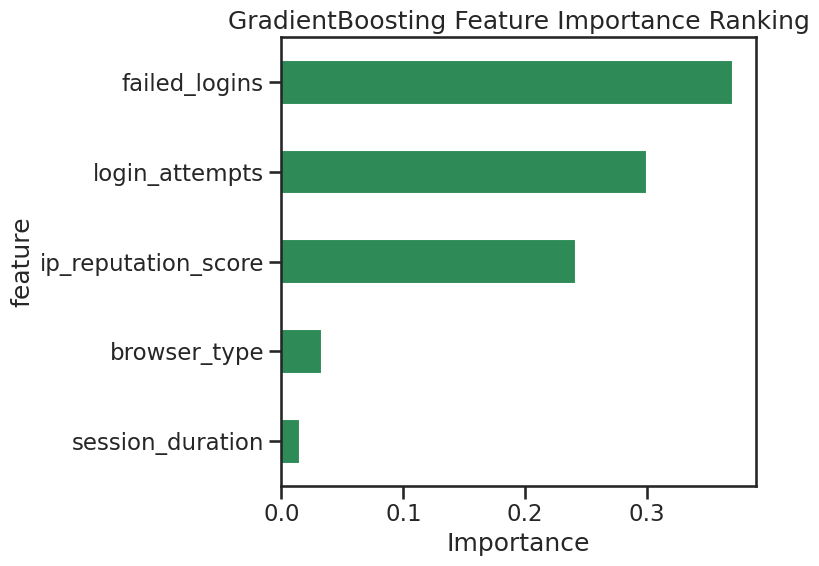

In [19]:
# Get the one hot encoded feature names from preprocessing and the matching importance scores from the model
importance_model = final_model_pipeline.named_steps["model"]
encoded_feature_names = final_model_pipeline.named_steps["preprocessor"].get_feature_names_out()
encoded_importances = importance_model.feature_importances_

# Map one hot encoded column names back to their original feature names
def collapse_feature_name(encoded_name):
    clean_name = encoded_name.replace("num__", "").replace("cat__", "")
    for column in X_train.columns:
        if clean_name == column or clean_name.startswith(f"{column}_"):
            return column
    return clean_name

# Get the top 5 features
importance_df = (
    pd.DataFrame({
        "feature": [collapse_feature_name(name) for name in encoded_feature_names],
        "importance": encoded_importances,
    })
    .groupby("feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
    .head(5)
    .reset_index(drop=True)
)

# Plot the top 5 features
importance_df.sort_values("importance", ascending=True).plot(kind="barh", x="feature", y="importance", 
                                                             figsize=(8, 6), legend=False, color="seagreen")
plt.title(f"{final_model_name} Feature Importance Ranking")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 12. Model Deployment: Flask Demo App

The final trained pipeline is saved with `joblib` so it can be loaded into the Flask app demo. The app collects session behavior, prepares the same features used during training, and returns a Normal/Attack prediction with probabilities of it being an `Attack`.

In [20]:
# Save the fitted final pipeline so the Flask app can load it directly for prediction.
model_save_path = Path("../web_app") / "final_model.joblib"
joblib.dump(final_model_pipeline, model_save_path)
print(str(model_save_path))

../web_app/final_model.joblib


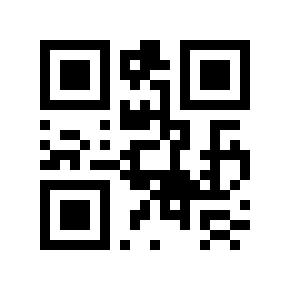

In [21]:
url = "google.com"
if not url:
    print("Add URL Code")
else:
    qr = qrcode.make(url)
    display(qr)

print()

## Username:   **admin**
## Password:   **password123**